In [1]:
from ultralytics import YOLO
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import torch
print("GPU détecté" if torch.cuda.is_available() else "Pas de GPU détecté")
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

GPU détecté


# Uploading YOLO model

In [3]:
model_yolo=YOLO("yolov8s.pt")

In [4]:
# Utilisation du gpu
model_yolo.to("cuda")

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

# Test image

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

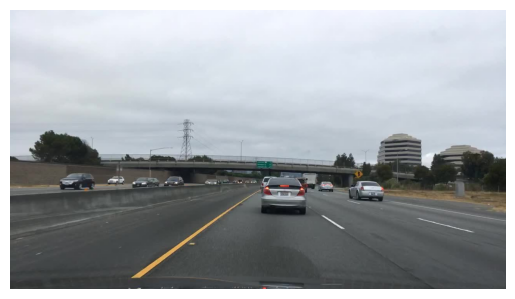

In [5]:
img = cv2.imread(r"../data/images/00de601c-858a8a8d.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [6]:
result=model_yolo(img)


0: 384x640 8 cars, 66.1ms
Speed: 6.1ms preprocess, 66.1ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)


## Display the bounding box

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

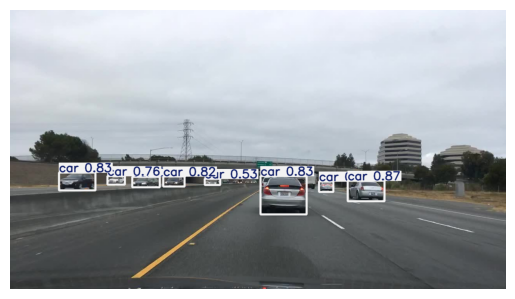

In [7]:
res_img = result[0].plot()

plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

## Origin and coordinates

In [8]:
for r in result: # Pour chaque résultat
    boxes=r.boxes # Récupération des détections d'image
    for box in boxes: # Pour chaque objet détecté
        x1,y1,x2,y2=box.xyxy[0] # Coordonnées bounding box, (x1,y1): coin haut gauche, (x2,y2): coin bas droite
        cls=int(box.cls[0]) # récupération du type d'objet
        print(cls)
        name=model_yolo.names[cls]
        print(name,float(x1),float(y1),float(x2),float(y2))

2
car 871.961181640625 440.72479248046875 966.308349609375 493.17486572265625
2
car 126.92196655273438 419.53424072265625 220.39108276367188 465.21087646484375
2
car 646.42626953125 428.944091796875 765.9840087890625 527.76708984375
2
car 395.99346923828125 429.29193115234375 450.37725830078125 455.85699462890625
2
car 797.417724609375 442.61224365234375 834.5576171875 469.609619140625
2
car 251.47203063964844 428.80596923828125 296.25390625 450.28570556640625
2
car 315.49627685546875 430.88006591796875 386.30169677734375 457.88897705078125
2
car 502.45086669921875 435.7691345214844 542.4962768554688 451.7011413574219


## Centering of the coordinates

In [9]:
x_center=(x1+x2)/2
y_center=(y1+y2)/2

In [10]:
for r in result:
    boxes=r.boxes
    for box in boxes:
        x1,y1,x2,y2=box.xyxy[0]
        cls=int(box.cls[0])
        name=model_yolo.names[cls]
        x_center=(x1+x2)/2
        y_center=(y1+y2)/2
        print(name,float(x_center),float(y_center))

car 919.134765625 466.9498291015625
car 173.65652465820312 442.37255859375
car 706.2051391601562 478.3555908203125
car 423.18536376953125 442.574462890625
car 815.9876708984375 456.1109313964844
car 273.86297607421875 439.54583740234375
car 350.89898681640625 444.384521484375
car 522.4735717773438 443.7351379394531


# Keeping just car and person

In [11]:
for r in result:  
    boxes = r.boxes
    for box in boxes:
        
        x1,y1,x2,y2 = box.xyxy[0]
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        name = model_yolo.names[cls]
        
        if name in ["car","person"] and conf > 0.5:
            
            x_center = float((x1 + x2) / 2)
            y_center = float((y1 + y2) / 2)
            
            print(name, x_center, y_center, conf)

car 919.134765625 466.9498291015625 0.869024395942688
car 173.65652465820312 442.37255859375 0.8311126828193665
car 706.2051391601562 478.3555908203125 0.8266839385032654
car 423.18536376953125 442.574462890625 0.8159389495849609
car 815.9876708984375 456.1109313964844 0.7565290331840515
car 273.86297607421875 439.54583740234375 0.7561360597610474
car 350.89898681640625 444.384521484375 0.7560484409332275
car 522.4735717773438 443.7351379394531 0.5274477601051331


# Tracking the frame

In [12]:
video_path="../data/videos/1.mp4"

cap=cv2.VideoCapture(video_path) # Lecture video

fps=cap.get(cv2.CAP_PROP_FPS) # Récupération du nombre d'images par secondes

print("FPS:", fps)

FPS: 30.001579030475288


Contient 30 images par secondes

Donc sur une video, le modèle va être lent donc nous devons réduire le nombre d'images

## Reduction in the number of images per second

In [13]:
dt = 0.2
frame_interval = int(fps * dt)

## YOLO + tracking

In [14]:
import glob
import cv2

video_paths = glob.glob("../data/videos/*.mp4")

data = []

for video_path in video_paths:
    
    print("Processing:", video_path)
    
    cap = cv2.VideoCapture(video_path)
    
    frame_id = 0
    saved_frame = 0

    while True:
        
        ret, frame = cap.read()  
        # frame : image lue
        # ret : booléen → True = lecture OK, False = fin vidéo ou problème

        if not ret:
            break

        # on fait le tracking sur TOUTES les frames
        # sinon les IDs deviennent instables
        result = model_yolo.track(frame, persist=True, verbose=False)
        # persist=True → garde la mémoire des objets entre les frames
        # verbose=False → supprime les logs YOLO

        # on ne garde qu'une frame sur N 
        if frame_id % frame_interval == 0:
            # ex: 30 fps → frame_interval = 6 → 1 frame toutes les 0.2 sec
            
            for r in result:  
                
                boxes = r.boxes

                if boxes.id is not None:  
                    # Certains résultats peuvent ne pas avoir d'ID
                    
                    ids = boxes.id.int().cpu().tolist()
                    # Transforme les IDs en liste Python classique
                    # .cpu() : Python ne sait pas lire les tensor Pytorch du GPU
                    # donc on les convertit en CPU

                    for box, obj_id in zip(boxes, ids):  
                        # Parcourt chaque objet détecté
                        
                        x1, y1, x2, y2 = box.xyxy[0]  
                        # coordonnées de la bounding box

                        cls = int(box.cls[0])  
                        # ID de classe (ex: 2 = car)

                        conf = float(box.conf[0])  
                        # score de confiance

                        name = model_yolo.names[cls]  
                        # conversion ID → nom ("car", "person", etc.)

                        if name in ["car", "truck", "bus", "motorcycle", "person"] and conf > 0.5:
                            
                            x_center = float((x1 + x2) / 2)
                            y_center = float((y1 + y2) / 2)
                            # centre de la bounding box → position de l'objet

                            data.append([
                                video_path.replace("\\", "/"),
                                saved_frame,
                                obj_id,
                                name,
                                x_center,
                                y_center,
                                conf
                            ])

                            # frame gardée numéro / objet ID / type / position centre / confiance

            saved_frame += 1  # on incrémente seulement quand on garde la frame

        frame_id += 1  # compteur global des frames

    cap.release()

Processing: ../data/videos\1.mp4
Processing: ../data/videos\10.mp4
Processing: ../data/videos\11.mp4
Processing: ../data/videos\12.mp4
Processing: ../data/videos\13.mp4
Processing: ../data/videos\14.mp4
Processing: ../data/videos\15.mp4
Processing: ../data/videos\16.mp4
Processing: ../data/videos\17.mp4
Processing: ../data/videos\18.mp4
Processing: ../data/videos\19.mp4
Processing: ../data/videos\2.mp4
Processing: ../data/videos\20.mp4
Processing: ../data/videos\21.mp4
Processing: ../data/videos\22.mp4
Processing: ../data/videos\3.mp4
Processing: ../data/videos\4.mp4
Processing: ../data/videos\5.mp4
Processing: ../data/videos\6.mp4
Processing: ../data/videos\7.mp4
Processing: ../data/videos\8.mp4
Processing: ../data/videos\9.mp4


## Data into DataFrame

In [15]:
import pandas as pd

df = pd.DataFrame(data,columns=["video","frame","object_id","type","x","y","conf"])
df.head()

,video,frame,object_id,type,x,y,conf
0,../data/videos/1.mp4,0,1,car,29.308987,354.123474,0.824250
1,../data/videos/1.mp4,1,1,car,39.238899,361.075714,0.740807
2,../data/videos/1.mp4,2,1,car,63.491207,366.220184,0.794936
3,../data/videos/1.mp4,2,5,car,379.851562,377.690430,0.624644
4,../data/videos/1.mp4,3,1,car,88.077667,372.178101,0.584235


In [16]:
df.shape

(4685, 7)

In [17]:
df["object_id"].nunique()

405

In [18]:
df["object_id"].unique()

array([   1,    5,   14,   26,   53,   55,   57,   65,   77,   96,  146,  212,  227,  360,  349,  365,  401,  403,  531,  620,  627,  633,  635,  638,  639,  643,  644,  646,  647,  649,  652,  653,  654,  655,  656,  659,  660,  662,  663,  665,  666,  672,  677,  680,  682,  683,  685,  687,  690,  713,  693,  718,
        724,  779,  799,  805,  920,  958,  953,  997, 1010, 1024, 1050, 1066, 1060, 1089, 1103, 1104, 1115, 1118, 1122, 1195, 1141, 1221, 1234, 1253, 1298, 1325, 1309, 1366, 1357, 1389, 1441, 1446, 1473, 1495, 1493, 1513, 1518, 1519, 1522, 1538, 1558, 1581, 1566, 1594, 1605, 1607, 1624, 1623, 1630, 1638, 1645, 1651,
       1652, 1657, 1674, 1676, 1677, 1685, 1686, 1698, 1699, 1703, 1704, 1707, 1727, 1730, 1734, 1745, 1751, 1752, 1784, 1781, 1809, 1826, 1829, 1837, 1845, 1849, 1855, 1860, 1861, 1863, 1893, 1920, 1913, 1937, 1946, 1931, 1966, 1972, 1967, 1987, 1996, 2000, 2007, 2015, 2016, 2036, 2046, 2047, 2048, 2049, 2050, 2058,
       2063, 2067, 2068, 2083, 2111, 2115, 

# Speed

In [19]:
df2 = df.copy()

In [20]:
df2 = df2.sort_values(["video","object_id","frame"])

df2["vx"] = df2.groupby(["video","object_id"])["x"].diff()
df2["vy"] = df2.groupby(["video","object_id"])["y"].diff()

In [21]:
df2.head()

,video,frame,object_id,type,x,y,conf,vx,vy
0,../data/videos/1.mp4,0,1,car,29.308987,354.123474,0.824250,NaN,NaN
1,../data/videos/1.mp4,1,1,car,39.238899,361.075714,0.740807,9.929913,6.952240
2,../data/videos/1.mp4,2,1,car,63.491207,366.220184,0.794936,24.252308,5.144470
4,../data/videos/1.mp4,3,1,car,88.077667,372.178101,0.584235,24.586460,5.957916
7,../data/videos/1.mp4,4,1,car,119.154434,375.172729,0.859832,31.076767,2.994629


In [22]:
df2.isna().sum()

video          0
frame          0
object_id      0
type           0
x              0
y              0
conf           0
vx           409
vy           409
dtype: int64

In [23]:
df2 = df2.dropna()

La vitesse est en pixels/frame (pixels entre 2 frame).
Les frames sont espacés de 0.2 secondes donc la vitesse doit etre divisé par 0.2

dt = frame_interval / fps

fps=30 donc 30 images par seconde

0.2 secondes entre 2 frames. Alors 6 frames par seconde (30x0.2)

In [24]:
dt = 0.2
frame_interval = int(fps * dt)

df2["vx"] = df2["vx"] / dt
df2["vy"] = df2["vy"] / dt

La vitesse est en pixel/seconde

In [25]:
df2.head(10)

,video,frame,object_id,type,x,y,conf,vx,vy
1,../data/videos/1.mp4,1,1,car,39.238899,361.075714,0.740807,49.649563,34.761200
2,../data/videos/1.mp4,2,1,car,63.491207,366.220184,0.794936,121.261539,25.722351
4,../data/videos/1.mp4,3,1,car,88.077667,372.178101,0.584235,122.932301,29.789581
7,../data/videos/1.mp4,4,1,car,119.154434,375.172729,0.859832,155.383835,14.973145
9,../data/videos/1.mp4,5,1,car,150.770248,379.420288,0.899769,158.079071,21.237793
11,../data/videos/1.mp4,6,1,car,193.421173,382.734497,0.905652,213.254623,16.571045
13,../data/videos/1.mp4,7,1,car,235.928619,387.137634,0.890928,212.537231,22.015686
15,../data/videos/1.mp4,8,1,car,279.663544,392.053741,0.876472,218.674622,24.580536
18,../data/videos/1.mp4,9,1,car,324.331299,398.946655,0.876350,223.338776,34.464569
21,../data/videos/1.mp4,10,1,car,367.970245,404.374603,0.893779,218.194733,27.139740


## Nombre de frame par objets suivis

In [30]:
df2.groupby(["video","object_id"]).size().sort_values(ascending=False).head(10)

video                  object_id
../data/videos/4.mp4   4766         182
../data/videos/2.mp4   3087         113
../data/videos/12.mp4  799           97
../data/videos/14.mp4  1518          89
../data/videos/3.mp4   3964          87
../data/videos/9.mp4   5349          80
../data/videos/8.mp4   5226          71
../data/videos/14.mp4  1581          65
../data/videos/9.mp4   5352          62
../data/videos/11.mp4  687           56
dtype: int64

In [31]:
df["type"].unique()

array(['car', 'person', 'truck', 'bus'], dtype=object)

In [34]:
df["type"].value_counts()

type
car       4302
truck      155
person     147
bus         81
Name: count, dtype: int64

Déséquilibre entre les classes mais le modèle apprend les positions et les mouvements donc pas d'impact sur l'apprentissage.

## Movement vizualisation

In [35]:
df2.head(20)

,video,frame,object_id,type,x,y,conf,vx,vy
1,../data/videos/1.mp4,1,1,car,39.238899,361.075714,0.740807,49.649563,34.761200
2,../data/videos/1.mp4,2,1,car,63.491207,366.220184,0.794936,121.261539,25.722351
4,../data/videos/1.mp4,3,1,car,88.077667,372.178101,0.584235,122.932301,29.789581
7,../data/videos/1.mp4,4,1,car,119.154434,375.172729,0.859832,155.383835,14.973145
9,../data/videos/1.mp4,5,1,car,150.770248,379.420288,0.899769,158.079071,21.237793
11,../data/videos/1.mp4,6,1,car,193.421173,382.734497,0.905652,213.254623,16.571045
13,../data/videos/1.mp4,7,1,car,235.928619,387.137634,0.890928,212.537231,22.015686
15,../data/videos/1.mp4,8,1,car,279.663544,392.053741,0.876472,218.674622,24.580536
18,../data/videos/1.mp4,9,1,car,324.331299,398.946655,0.876350,223.338776,34.464569
21,../data/videos/1.mp4,10,1,car,367.970245,404.374603,0.893779,218.194733,27.139740


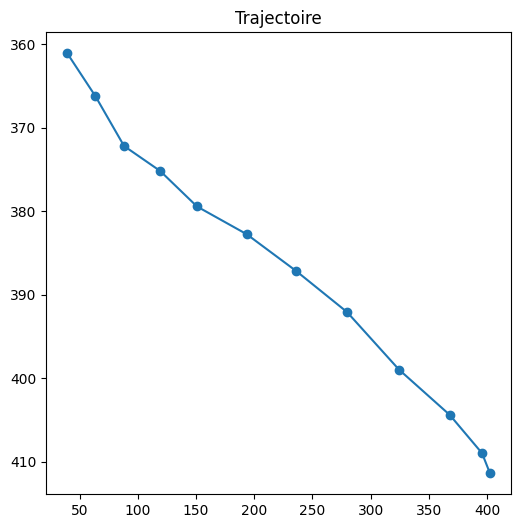

In [40]:
import matplotlib.pyplot as plt

obj = df2[(df2["video"]=="../data/videos/1.mp4") & (df2["object_id"] == 1)]

plt.figure(figsize=(6,6))

plt.plot(obj["x"], obj["y"], marker="o")

plt.gca().invert_yaxis()
# Dans OpenCV, (0,0) → coin en haut à gauche et inversé dans Matplotlib
plt.title("Trajectoire")
plt.show()

# Managing the data

In [41]:
df2.columns

Index(['video', 'frame', 'object_id', 'type', 'x', 'y', 'conf', 'vx', 'vy'], dtype='object')

### Video size

In [42]:
video_sizes = {}

for video_path in df2["video"].unique():
    
    cap = cv2.VideoCapture(video_path)
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    video_sizes[video_path] = (width, height)
    
    cap.release()

In [43]:
video_sizes

{'../data/videos/1.mp4': (478, 850),
 '../data/videos/10.mp4': (478, 850),
 '../data/videos/11.mp4': (478, 850),
 '../data/videos/12.mp4': (478, 850),
 '../data/videos/13.mp4': (478, 850),
 '../data/videos/14.mp4': (478, 850),
 '../data/videos/15.mp4': (478, 850),
 '../data/videos/16.mp4': (478, 850),
 '../data/videos/17.mp4': (478, 850),
 '../data/videos/18.mp4': (478, 850),
 '../data/videos/19.mp4': (478, 850),
 '../data/videos/2.mp4': (478, 850),
 '../data/videos/20.mp4': (478, 850),
 '../data/videos/21.mp4': (478, 850),
 '../data/videos/22.mp4': (478, 850),
 '../data/videos/3.mp4': (478, 850),
 '../data/videos/4.mp4': (478, 850),
 '../data/videos/5.mp4': (478, 850),
 '../data/videos/6.mp4': (478, 850),
 '../data/videos/7.mp4': (478, 850),
 '../data/videos/8.mp4': (478, 850),
 '../data/videos/9.mp4': (478, 850)}

### Normalization

In [44]:
def normalize(row):
    w, h = video_sizes[row["video"]]
    
    row["x"] /= w
    row["y"] /= h
    row["vx"] /= w
    row["vy"] /= h
    
    return row

df2 = df2.apply(normalize, axis=1)

In [45]:
df2.head()

,video,frame,object_id,type,x,y,conf,vx,vy
1,../data/videos/1.mp4,1,1,car,0.082090,0.424795,0.740807,0.103869,0.040896
2,../data/videos/1.mp4,2,1,car,0.132827,0.430847,0.794936,0.253685,0.030262
4,../data/videos/1.mp4,3,1,car,0.184263,0.437857,0.584235,0.257181,0.035047
7,../data/videos/1.mp4,4,1,car,0.249277,0.441380,0.859832,0.325071,0.017615
9,../data/videos/1.mp4,5,1,car,0.315419,0.446377,0.899769,0.330709,0.024986


### Création des séquences pour l'apprentissage (x,y)

In [46]:
sequence_length=3
feature_cols=['x','y','vx','vy']

df_seq=df2.copy()
df_seq=df_seq.sort_values(["video","object_id","frame"]).reset_index(drop=True)

# sequence de 4 frame (3 entrée et 1 sortie)
min_len = sequence_length + 1

traj_sizes = (df_seq.groupby(["video", "object_id"]).size().reset_index(name="traj_len"))

valid_traj = traj_sizes[traj_sizes["traj_len"] >= min_len][["video", "object_id"]]

df_seq = df_seq.merge(valid_traj, on=["video","object_id"],how="inner")

# Création de séquences
x_list=[]
y_list=[]

for (video,obj_id), group in df_seq.groupby(["video","object_id"]): # Chaque groupe correspond à un seul objet dans une seule video

    # ordre temporel
    group = group.sort_values("frame") # on s’assure que les frames sont bien dans l’ordre.

    # Etats de l'objet
    states=group[feature_cols].to_numpy(dtype="float32") # On récupère uniquement x,y,vx,vy et conversion en tableau numpy (standard pour TensorFlow)

    # fenêtre glissante
    n_sample=len(states) - sequence_length # nombre de séquences qu’on peut extraire de cette trajectoire

    for i in range(n_sample):
        x_seq=states[i:i+sequence_length] # [t1...t3]
        y_seq=states[i+sequence_length] # t4

        x_list.append(x_seq)
        y_list.append(y_seq)

# Conversion en tableau numpy
X=np.array(x_list,dtype=np.float32)
y=np.array(y_list,dtype=np.float32)

# X aura la forme (N, 5, 4)
# y aura la forme (N, 4)

# N = nombre total d’exemples
# 5 = longueur de séquence
# 4 = nombre de features


In [47]:
# Vérification
print("X shape :", X.shape)
print("y shape :", y.shape)

print("\nExemple X[0] :")
print(X[0])
print("\nExemple y[0] :")
print(y[0])

X shape : (3426, 3, 4)
y shape : (3426, 4)

Exemple X[0] :
[[    0.08209     0.42479     0.10387    0.040896]
 [    0.13283     0.43085     0.25369    0.030262]
 [    0.18426     0.43786     0.25718    0.035047]]

Exemple y[0] :
[    0.24928     0.44138     0.32507    0.017615]


# Model for prediction

In [48]:
import tensorflow as tf
from tensorflow.keras import layers

model=tf.keras.Sequential([
    layers.Input(shape=(3,4)),
    #layers.Flatten(),
    #layers.Dense(64,activation="relu"),
    layers.LSTM(64,return_sequences=False), # Enlever Flatten si LSTM et le dense au dessus
    layers.Dense(64,activation="relu"),
    layers.Dense(4)
])

In [49]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [50]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])

In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,084 (86.27 KB)

 Trainable params: 22,084 (86.27 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history=model.fit(X,y,epochs=20,batch_size=32,validation_split=0.2,callbacks=[early_stop])

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0236 - mae: 0.0866 - val_loss: 0.0014 - val_mae: 0.0227
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0231 - val_loss: 0.0010 - val_mae: 0.0203
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - mae: 0.0213 - val_loss: 8.3138e-04 - val_mae: 0.0174
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - mae: 0.0195 - val_loss: 6.7685e-04 - val_mae: 0.0150
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - mae: 0.0179 - val_loss: 6.8449e-04 - val_mae: 0.0148
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015 - mae: 0.0171 - val_loss: 6.2784e-04 - val_mae: 0.0145
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - mae: 0.0160 - val_loss: 5.6091e-04 - val_mae: 0.0125
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - mae: 0.0151 - val_loss: 5.0980e-04 - val_mae: 0.0113
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

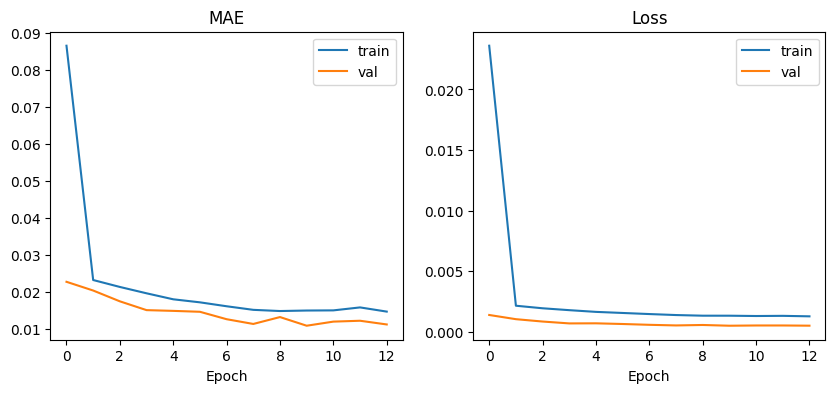

In [53]:
plt.figure(figsize=(10,4))

# MAE
plt.subplot(1,2,1)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.xlabel("Epoch")
plt.legend()

# LOSS
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.show()

In [67]:
val_mae = history.history['val_mae'][-1]
val_mae

0.011113903485238552

In [73]:
val_mae = history.history['val_mae'][-1]
y_mean=np.mean(np.abs(y))
val_mae*100/y_mean

np.float32(3.900566)

Le modèle fait une erreur moyenne de 3.9% 

Le modèle a appris l'inertie, la direction, la vitesse ett la continuité.

## Prediction

In [54]:
def predict_future(model, init_seq, steps=10):
    
    seq = init_seq.copy()
    preds = []
    
    for _ in range(steps):
        
        pred = model.predict(seq[np.newaxis], verbose=0)[0]
        
        preds.append(pred)
        
        # fenêtre glissante
        seq = np.vstack([seq[1:], pred])
    
    return np.array(preds)

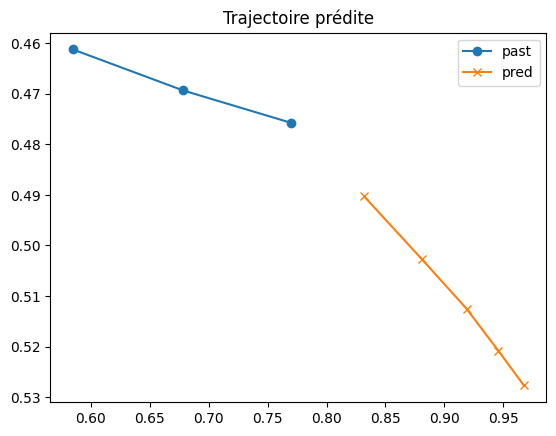

In [55]:
# prendre un exemple
idx = 7

init_seq = X[idx]
true_future = y[idx]

preds = predict_future(model, init_seq, steps=5)

# concaténer pour afficher
past = init_seq[:, :2]       # x,y
future_pred = preds[:, :2]

plt.figure()

# passé
plt.plot(past[:,0], past[:,1], marker="o", label="past")

# prédiction
plt.plot(future_pred[:,0], future_pred[:,1], marker="x", label="pred")


plt.gca().invert_yaxis()
plt.legend()
plt.title("Trajectoire prédite")
plt.show()

In [57]:
model.save("../models/world_model.keras")